<a href="https://colab.research.google.com/github/citraanandapratiwi6-rgb/machine-learning/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [20]:
# IMPORT DATA

# Membaca file CSV
df = pd.read_csv('/content/data_balanced.csv')

# Menampilkan 5 baris pertama dari dataset
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,82450.0,1.314539,0.590643,-0.666593,0.716564,0.301978,-1.125467,0.388881,-0.288390,-0.132137,...,-0.170307,-0.429655,-0.141341,-0.200195,0.639491,0.399476,-0.034321,0.031692,0.76,0
1,50554.0,-0.798672,1.185093,0.904547,0.694584,0.219041,-0.319295,0.495236,0.139269,-0.760214,...,0.202287,0.578699,-0.092245,0.013723,-0.246466,-0.380057,-0.396030,-0.112901,4.18,0
2,55125.0,-0.391128,-0.245540,1.122074,-1.308725,-0.639891,0.008678,-0.701304,-0.027315,-2.628854,...,-0.133485,0.117403,-0.191748,-0.488642,-0.309774,0.008100,0.163716,0.239582,15.00,0
3,116572.0,-0.060302,1.065093,-0.987421,-0.029567,0.176376,-1.348539,0.775644,0.134843,-0.149734,...,0.355576,0.907570,-0.018454,-0.126269,-0.339923,-0.150285,-0.023634,0.042330,57.00,0
4,90434.0,1.848433,0.373364,0.269272,3.866438,0.088062,0.970447,-0.721945,0.235983,0.683491,...,0.103563,0.620954,0.197077,0.692392,-0.206530,-0.021328,-0.019823,-0.042682,0.00,0


In [21]:
# EKSPROLASI DATA

# Menampilkan informasi umum dataset
df.info()

# Menampilkan statistik deskriptif dari data numerik
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    984 non-null    float64
 1   V1      984 non-null    float64
 2   V2      984 non-null    float64
 3   V3      984 non-null    float64
 4   V4      984 non-null    float64
 5   V5      984 non-null    float64
 6   V6      984 non-null    float64
 7   V7      984 non-null    float64
 8   V8      984 non-null    float64
 9   V9      984 non-null    float64
 10  V10     984 non-null    float64
 11  V11     984 non-null    float64
 12  V12     984 non-null    float64
 13  V13     984 non-null    float64
 14  V14     984 non-null    float64
 15  V15     984 non-null    float64
 16  V16     984 non-null    float64
 17  V17     984 non-null    float64
 18  V18     984 non-null    float64
 19  V19     984 non-null    float64
 20  V20     984 non-null    float64
 21  V21     984 non-null    float64
 22  V2

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,...,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,87899.782520,-2.309318,1.816713,-3.535655,2.257353,-1.544629,-0.725850,-2.777468,0.292773,-1.271887,...,0.363824,-0.003366,-0.013543,-0.056194,0.033048,0.011976,0.090822,0.036681,101.279837,0.500000
std,47991.767211,5.523248,3.675483,6.200540,3.207699,4.205316,1.726953,5.845730,4.859601,2.340829,...,2.806097,1.170228,1.164365,0.578977,0.677074,0.469889,0.999413,0.415091,221.764524,0.500254
min,406.000000,-30.552380,-8.402154,-31.103685,-4.519509,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.836627,-4.781606,-1.178778,-7.263482,-1.869290,0.000000,0.000000
25%,45928.000000,-2.784711,-0.150957,-5.084967,-0.140560,-1.775001,-1.599839,-3.066415,-0.228822,-2.353917,...,-0.164947,-0.541855,-0.245208,-0.399495,-0.309954,-0.297013,-0.062727,-0.056989,1.180000,0.000000
50%,80853.000000,-0.784459,0.940617,-1.369045,1.302623,-0.340291,-0.671683,-0.635248,0.146863,-0.702318,...,0.136882,0.035879,-0.035509,0.009479,0.058178,-0.014392,0.042484,0.031986,16.880000,0.500000
75%,134528.250000,1.125429,2.798885,0.225959,4.202830,0.492184,0.073437,0.286374,0.867939,0.192528,...,0.655130,0.553477,0.192580,0.381696,0.401022,0.289880,0.455390,0.211934,99.990000,1.000000
max,171917.000000,2.351891,22.057729,3.143387,12.114672,11.095089,6.474115,5.802537,20.007208,5.232322,...,27.202839,8.361985,6.008724,1.205581,2.208209,2.745261,3.052358,1.779364,2125.870000,1.000000


DATA PREPROCESSING

In [22]:
# MISSING VALUE

#Cek Missing Value
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [23]:
# MENGHAPUS OUTLIER

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# filter data (hapus outlier)
df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

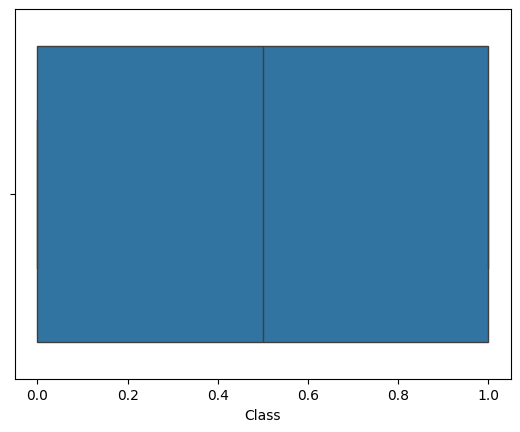

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat boxplot untuk melihat distribusi data pada kolom 'Class'
sns.boxplot(x=df['Class'])

# Menampilkan grafik
plt.show()

In [25]:
# PISAHKAN FITUR DAN TARGET

# X (fitur) = semua kolom kecuali 'Class'
X = df.drop('Class', axis=1)             # axis=1 artinya kita menghapus kolom

# y (target) = kolom 'Class'
y = df['Class']               # berisi label yang ingin diprediksi

In [26]:
# STANDARISASI

# Membuat objek scaler
scaler = StandardScaler()

# Melakukan standarisasi pada fitur (X)
X_scaled = scaler.fit_transform(X)

Exploratory Data Analysis (EDA)

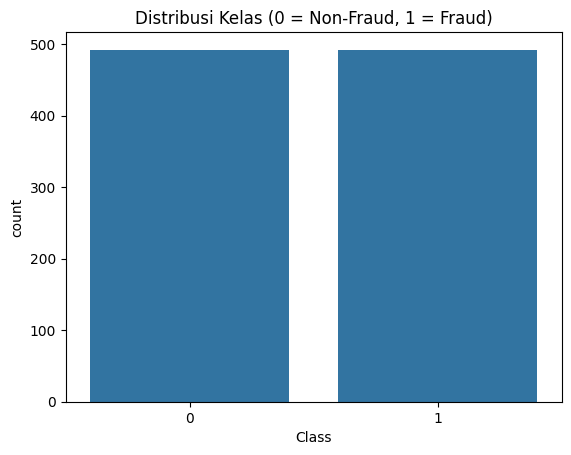

In [27]:
# DISTRIBUSI KELAS

import matplotlib.pyplot as plt
import seaborn as sns


# Membuat countplot untuk melihat jumlah data pada tiap kelas
sns.countplot(x='Class', data=df)

# Menambahkan judul grafik
plt.title('Distribusi Kelas (0 = Non-Fraud, 1 = Fraud)')

# Menampilkan grafik
plt.show()

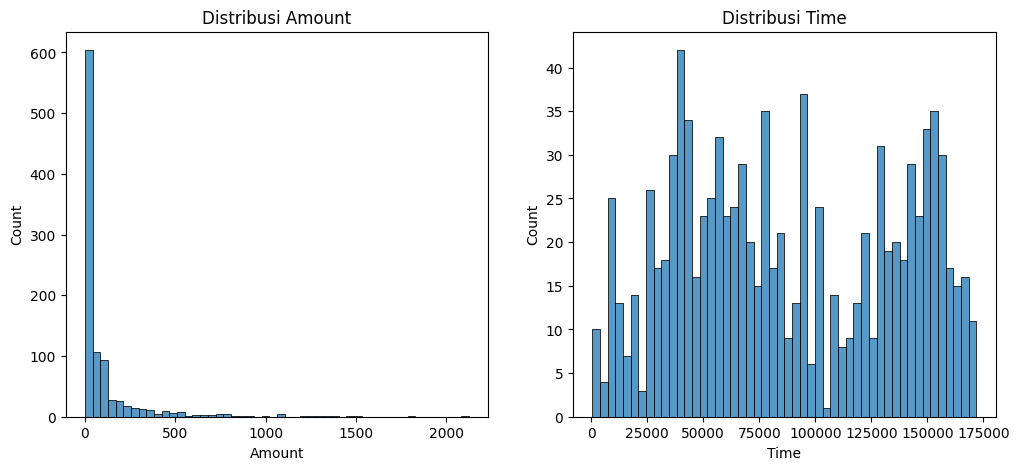

In [28]:
# Mengatur ukuran figure (lebar 12, tinggi 5)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1) # 1 baris, 2 kolom, posisi ke-1
sns.histplot(df['Amount'], bins=50)
plt.title('Distribusi Amount')

plt.subplot(1,2,2)
sns.histplot(df['Time'], bins=50)
plt.title('Distribusi Time')

plt.show()

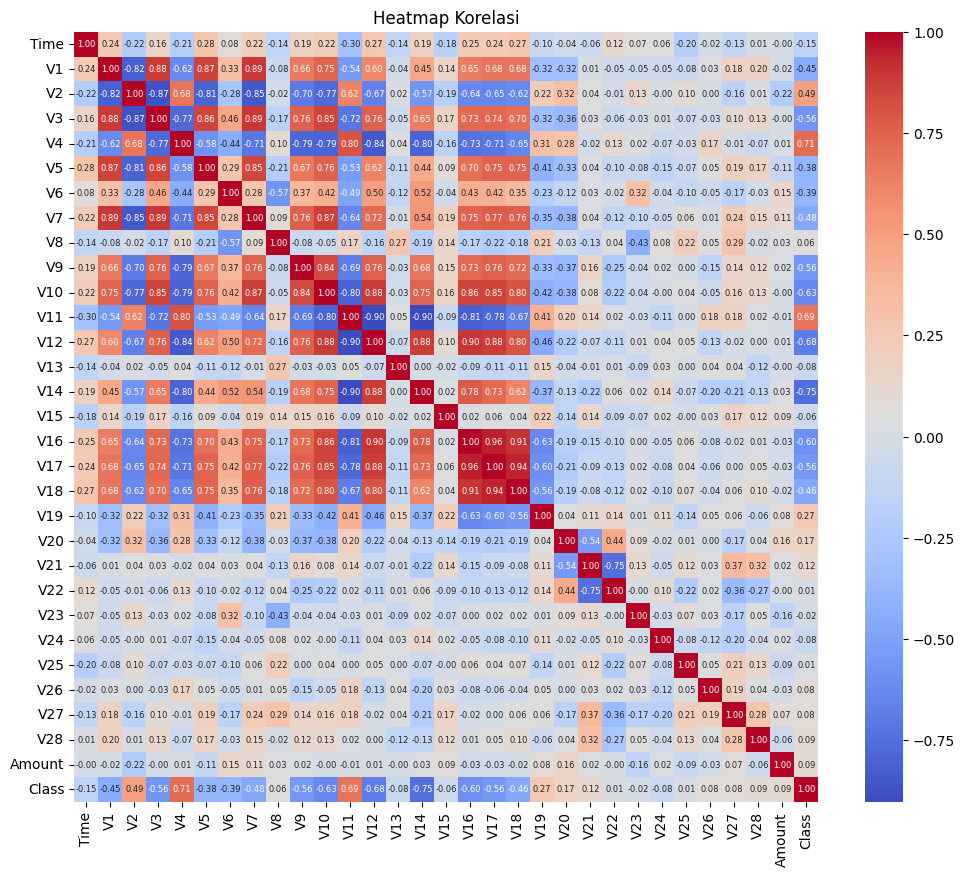

In [29]:
# KORELASI ANTARA VARIABEL

# Mengatur ukuran figure (lebar 12, tinggi 10)
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True, fmt='.2f', annot_kws={"size":6})
plt.title('Heatmap Korelasi')
plt.show()

Data Splitting

In [30]:
#data splitting (70% training : 30% testing)
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("70:30")
print("Train:", X_train_70.shape)
print("Test :", X_test_30.shape)

#data splitting (80% training : 20% testing)
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("80:20")
print("Train:", X_train_80.shape)
print("Test :", X_test_20.shape)

#data splitting (90% training : 10% testing)
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

print("90:10")
print("Train:", X_train_90.shape)
print("Test :", X_test_10.shape)

70:30
Train: (688, 30)
Test : (296, 30)
80:20
Train: (787, 30)
Test : (197, 30)
90:10
Train: (885, 30)
Test : (99, 30)


Hyperparameter Tuning & Model Evaluation

NAIVE BAYES

In [31]:
from sklearn.naive_bayes import GaussianNB
import numpy as np

# MENENTUKAN HYPERPARAMETER
param_grid = {
    'var_smoothing': np.logspace(-9, -1, 9)
}

# MEMBUAT MODEL GRID SEARCH
grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# TRAINING + TUNING (70:30)
grid_nb.fit(X_train_70, y_train_70) # Melatih model dengan data training
best_nb_70 = grid_nb.best_estimator_ # Mengambil model terbaik hasil tuning
y_pred_70 = best_nb_70.predict(X_test_30) # Melakukan prediksi pada data testing

# Menampilkan hasil evaluasi model
print("Naive Bayes (70:30) - TUNED")
print("Best Params:", grid_nb.best_params_)
print("Accuracy :", accuracy_score(y_test_30, y_pred_70))
print("Precision:", precision_score(y_test_30, y_pred_70, zero_division=0))
print("Recall   :", recall_score(y_test_30, y_pred_70, zero_division=0))
print("F1 Score :", f1_score(y_test_30, y_pred_70))
print("Confusion Matrix:\n", confusion_matrix(y_test_30, y_pred_70))

# TRAINING + TUNING (80:20)
grid_nb.fit(X_train_80, y_train_80)
best_nb_80 = grid_nb.best_estimator_
y_pred_80 = best_nb_80.predict(X_test_20)

print("Naive Bayes (80:20) - TUNED")
print("Best Params:", grid_nb.best_params_)
print("Accuracy :", accuracy_score(y_test_20, y_pred_80))
print("Precision:", precision_score(y_test_20, y_pred_80, zero_division=0))
print("Recall   :", recall_score(y_test_20, y_pred_80, zero_division=0))
print("F1 Score :", f1_score(y_test_20, y_pred_80))
print("Confusion Matrix:\n", confusion_matrix(y_test_20, y_pred_80))

# TRAINING + TUNING (90:10)
grid_nb.fit(X_train_90, y_train_90)
best_nb_90 = grid_nb.best_estimator_
y_pred_90 = best_nb_90.predict(X_test_10)

print("Naive Bayes (90:10) - TUNED")
print("Best Params:", grid_nb.best_params_)
print("Accuracy :", accuracy_score(y_test_10, y_pred_90))
print("Precision:", precision_score(y_test_10, y_pred_90, zero_division=0))
print("Recall   :", recall_score(y_test_10, y_pred_90, zero_division=0))
print("F1 Score :", f1_score(y_test_10, y_pred_90))
print("Confusion Matrix:\n", confusion_matrix(y_test_10, y_pred_90))

Naive Bayes (70:30) - TUNED
Best Params: {'var_smoothing': np.float64(1e-09)}
Accuracy : 0.847972972972973
Precision: 0.9904761904761905
Recall   : 0.7027027027027027
F1 Score : 0.8221343873517787
Confusion Matrix:
 [[147   1]
 [ 44 104]]
Naive Bayes (80:20) - TUNED
Best Params: {'var_smoothing': np.float64(1e-09)}
Accuracy : 0.8629441624365483
Precision: 0.9863013698630136
Recall   : 0.7346938775510204
F1 Score : 0.8421052631578947
Confusion Matrix:
 [[98  1]
 [26 72]]
Naive Bayes (90:10) - TUNED
Best Params: {'var_smoothing': np.float64(1e-09)}
Accuracy : 0.8484848484848485
Precision: 0.9722222222222222
Recall   : 0.7142857142857143
F1 Score : 0.8235294117647058
Confusion Matrix:
 [[49  1]
 [14 35]]


DECISION TREE

In [32]:
# ==========================
# IMPORT LIBRARY
# ==========================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# ==========================
# MENENTUKAN HYPERPARAMETER
# ==========================
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}

# ==========================
# MEMBUAT GRID SEARCH
# ==========================

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# ==========================
# TRAINING + TUNING (70:30)
# ==========================

grid_dt.fit(X_train_70, y_train_70)

# Model terbaik hasil tuning
best_dt_70 = grid_dt.best_estimator_

# Prediksi ke data testing (inferensi)
y_pred_70 = best_dt_70.predict(X_test_30)

# Evaluasi model
print("Decision Tree (70:30) - TUNED")
print("Best Params:", grid_dt.best_params_)
print("Accuracy :", accuracy_score(y_test_30, y_pred_70))
print("Precision:", precision_score(y_test_30, y_pred_70, zero_division=0))
print("Recall   :", recall_score(y_test_30, y_pred_70, zero_division=0))
print("F1 Score :", f1_score(y_test_30, y_pred_70))
print("Confusion Matrix:\n", confusion_matrix(y_test_30, y_pred_70))


# ==========================
# TRAINING + TUNING (80:20)
# ==========================

grid_dt.fit(X_train_80, y_train_80)
best_dt_80 = grid_dt.best_estimator_
y_pred_80 = best_dt_80.predict(X_test_20)

print("\nDecision Tree (80:20) - TUNED")
print("Best Params:", grid_dt.best_params_)
print("Accuracy :", accuracy_score(y_test_20, y_pred_80))
print("Precision:", precision_score(y_test_20, y_pred_80, zero_division=0))
print("Recall   :", recall_score(y_test_20, y_pred_80, zero_division=0))
print("F1 Score :", f1_score(y_test_20, y_pred_80))
print("Confusion Matrix:\n", confusion_matrix(y_test_20, y_pred_80))


# ==========================
# TRAINING + TUNING (90:10)
# ==========================

grid_dt.fit(X_train_90, y_train_90)
best_dt_90 = grid_dt.best_estimator_
y_pred_90 = best_dt_90.predict(X_test_10)

print("\nDecision Tree (90:10) - TUNED")
print("Best Params:", grid_dt.best_params_)
print("Accuracy :", accuracy_score(y_test_10, y_pred_90))
print("Precision:", precision_score(y_test_10, y_pred_90, zero_division=0))
print("Recall   :", recall_score(y_test_10, y_pred_90, zero_division=0))
print("F1 Score :", f1_score(y_test_10, y_pred_90))
print("Confusion Matrix:\n", confusion_matrix(y_test_10, y_pred_90))

Decision Tree (70:30) - TUNED
Best Params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Accuracy : 0.9087837837837838
Precision: 0.9060402684563759
Recall   : 0.9121621621621622
F1 Score : 0.9090909090909091
Confusion Matrix:
 [[134  14]
 [ 13 135]]

Decision Tree (80:20) - TUNED
Best Params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
Accuracy : 0.9187817258883249
Precision: 0.9019607843137255
Recall   : 0.9387755102040817
F1 Score : 0.92
Confusion Matrix:
 [[89 10]
 [ 6 92]]

Decision Tree (90:10) - TUNED
Best Params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Accuracy : 0.9191919191919192
Precision: 0.9183673469387755
Recall   : 0.9183673469387755
F1 Score : 0.9183673469387755
Confusion Matrix:
 [[46  4]
 [ 4 45]]


LOGISTIC REGRESSION

In [33]:
# ==========================
# IMPORT LIBRARY
# ==========================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# ==========================
# MENENTUKAN HYPERPARAMETER
# ==========================
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced']
}

# ==========================
# MEMBUAT GRID SEARCH
# ==========================

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# ==========================
# TRAINING + TUNING (70:30)
# ==========================

grid_lr.fit(X_train_70, y_train_70)

# Model terbaik hasil tuning
best_lr_70 = grid_lr.best_estimator_

# Prediksi ke data testing (inferensi)
y_pred_70 = best_lr_70.predict(X_test_30)

# Evaluasi model
print("Logistic Regression (70:30) - TUNED")
print("Best Params:", grid_lr.best_params_)
print("Accuracy :", accuracy_score(y_test_30, y_pred_70))
print("Precision:", precision_score(y_test_30, y_pred_70, zero_division=0))
print("Recall   :", recall_score(y_test_30, y_pred_70, zero_division=0))
print("F1 Score :", f1_score(y_test_30, y_pred_70))
print("Confusion Matrix:\n", confusion_matrix(y_test_30, y_pred_70))


# ==========================
# TRAINING + TUNING (80:20)
# ==========================

grid_lr.fit(X_train_80, y_train_80)
best_lr_80 = grid_lr.best_estimator_
y_pred_80 = best_lr_80.predict(X_test_20)

print("\nLogistic Regression (80:20) - TUNED")
print("Best Params:", grid_lr.best_params_)
print("Accuracy :", accuracy_score(y_test_20, y_pred_80))
print("Precision:", precision_score(y_test_20, y_pred_80, zero_division=0))
print("Recall   :", recall_score(y_test_20, y_pred_80, zero_division=0))
print("F1 Score :", f1_score(y_test_20, y_pred_80))
print("Confusion Matrix:\n", confusion_matrix(y_test_20, y_pred_80))


# ==========================
# TRAINING + TUNING (90:10)
# ==========================

grid_lr.fit(X_train_90, y_train_90)
best_lr_90 = grid_lr.best_estimator_
y_pred_90 = best_lr_90.predict(X_test_10)

print("\nLogistic Regression (90:10) - TUNED")
print("Best Params:", grid_lr.best_params_)
print("Accuracy :", accuracy_score(y_test_10, y_pred_90))
print("Precision:", precision_score(y_test_10, y_pred_90, zero_division=0))
print("Recall   :", recall_score(y_test_10, y_pred_90, zero_division=0))
print("F1 Score :", f1_score(y_test_10, y_pred_90))
print("Confusion Matrix:\n", confusion_matrix(y_test_10, y_pred_90))

Logistic Regression (70:30) - TUNED
Best Params: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy : 0.9425675675675675
Precision: 0.9455782312925171
Recall   : 0.9391891891891891
F1 Score : 0.9423728813559322
Confusion Matrix:
 [[140   8]
 [  9 139]]

Logistic Regression (80:20) - TUNED
Best Params: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy : 0.949238578680203
Precision: 0.9489795918367347
Recall   : 0.9489795918367347
F1 Score : 0.9489795918367347
Confusion Matrix:
 [[94  5]
 [ 5 93]]

Logistic Regression (90:10) - TUNED
Best Params: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy : 0.9292929292929293
Precision: 0.92
Recall   : 0.9387755102040817
F1 Score : 0.9292929292929293
Confusion Matrix:
 [[46  4]
 [ 3 46]]


INFERENCE

In [34]:
# ===============================
# INFERENCE
# ===============================

import pandas as pd

# data baru
data_baru = pd.DataFrame({
    'Time': [50000],
    'Amount': [1200],
    'V1': [-1.25],
    'V2': [0.45],
    'V3': [1.22],
    'V4': [0.75],
    'V5': [-0.12],
    'V6': [0.33],
    'V7': [-0.55],
    'V8': [0.14],
    'V9': [0.25],
    'V10': [-0.44],
    'V11': [1.11],
    'V12': [-0.87],
    'V13': [0.52],
    'V14': [-0.65],
    'V15': [0.33],
    'V16': [-0.28],
    'V17': [0.47],
    'V18': [0.29],
    'V19': [-0.18],
    'V20': [0.12],
    'V21': [-0.05],
    'V22': [0.07],
    'V23': [0.11],
    'V24': [0.08],
    'V25': [0.02],
    'V26': [0.03],
    'V27': [-0.01],
    'V28': [0.01]
})

# samakan urutan kolom seperti data training
data_baru = data_baru[X.columns]

# scaling
data_baru_scaled = scaler.transform(data_baru)

# ubah ke DataFrame agar ada nama kolom
data_baru_scaled = pd.DataFrame(data_baru_scaled, columns=X.columns)

# model terbaik
model_terbaik = grid_lr.best_estimator_

# prediksi
hasil = model_terbaik.predict(data_baru_scaled)
prob = model_terbaik.predict_proba(data_baru_scaled)

# output
if hasil[0] == 1:
    print("Transaksi FRAUD")
else:
    print("Transaksi NORMAL")

print("Probabilitas Normal :", prob[0][0])
print("Probabilitas Fraud  :", prob[0][1])

Transaksi NORMAL
Probabilitas Normal : 0.9999430688435685
Probabilitas Fraud  : 5.693115643151656e-05
